# 32 — Particle tracking vs. July 2025 drifter deploys

**Goal:** reproduce the 12 Stokes-drifter deploys from the July 2025 field campaign with a Lagrangian particle tracking run driven by the v04 D-Flow FM surface velocity field, then score skill per deploy.

**Data:** `drifters_Jul25_polished.csv` — columns: `Data Date; Sea Surface; x_coord; y_coord; source; deploy; Distance; Time step; Velocity; deltaX; deltaY; quadrante; Direction; Direction N; ...`. Coordinates are UTM Zone 33N (EPSG:32633). Rows with `deploy=altri` are between-deploy drift / anomalies — excluded here.

**Approach (v04 + OpenDrift):**
1. Parse and QC drifter CSV (Italian locale, semicolon separator, comma decimals, mixed date formats)
2. Group by `(deploy, source)` → one drifter track each; first valid row = release (t₀, x₀, y₀)
3. Convert UTM33N → WGS84 to match v04 mesh CRS
4. Run Lagrangian tracking with **OpenDrift** (`OceanDrift` + `reader_netCDF_CF_generic`) over the regridded v04 surface current field (with 10-m wind packed in the same NetCDF for windage)
5. Score trajectory skill per deploy: endpoint separation, path-length ratio, Liu & Weisberg skill

**Why regridded input to OpenDrift:** OpenDrift's native readers don't accept D-Flow FM unstructured partitioned output directly (`reader_netCDF_CF_unstructured` requires Cartesian coords, `reader_FVCOM_xarray` needs FVCOM-specific time vars). Simplest path: regrid the 8 MPI-partitioned map.nc onto a rectilinear 0.002° (~200 m) lat-lon grid covering July 7-10 and save as a CF-compliant NetCDF (`data/processed/v04_surface_current.nc`) via `scripts/regrid_v04_for_opendrift.py`. The same file packs `x_wind`/`y_wind` (CF standard names) so OpenDrift's generic reader picks them up automatically and applies the per-element windage.

**OpenDrift advantages over a naive tracker:**
- Well-tested RK4 advection with proper mesh masking
- Stokes drift, windage, horizontal random-walk diffusion configurable
- Coastline bounce-back handling
- Trajectory output in standard NetCDF format

An earlier version of this notebook used a custom RK2 tracker over v03a output — it has been replaced by the OpenDrift pipeline documented below, now reading from v04.

## 1. Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pyproj import Transformer

_cwd = Path.cwd().resolve()
project_root = _cwd.parent if _cwd.name == 'notebooks' else _cwd
raw_dir = project_root / 'data' / 'raw' / 'insitu'
processed_dir = project_root / 'data' / 'processed'
fig_dir = project_root / 'figures'
processed_dir.mkdir(parents=True, exist_ok=True)
print(f'Project root: {project_root}')

drifter_csv = raw_dir / 'drifters_Jul25_polished.csv'

# v04rAE output (re-run Jul 8-9 from restart, mapInterval=600s, AE-only blend
# = ERA5+AE without Mulino, per the implied-wind weights diagnostic showing
# Mulino weight ~ 0).
v04rAE_output = project_root / 'model' / 'dflowfm_v04rAE' / 'DFM_OUTPUT_Stagnone_dxy01_15m'
v04rAE_map_pattern = str(v04rAE_output / 'Stagnone_dxy01_15m_0*_map.nc')

print(f'Drifter CSV exists: {drifter_csv.exists()}  ({drifter_csv})')
print(f'v04rAE map pattern: {v04rAE_map_pattern}')
partitions_found = list(v04rAE_output.glob('Stagnone_dxy01_15m_0*_map.nc'))
print(f'Partitions matching wildcard: {len(partitions_found)}')
for p in sorted(partitions_found):
    print(f'  {p.name}  ({p.stat().st_size / 1e9:.2f} GB)')

Project root: C:\Users\Unipa\Documents\StagnoneDT
Drifter CSV exists: True  (C:\Users\Unipa\Documents\StagnoneDT\data\raw\insitu\drifters_Jul25_polished.csv)
v04rAE map pattern: C:\Users\Unipa\Documents\StagnoneDT\model\dflowfm_v04rAE\DFM_OUTPUT_Stagnone_dxy01_15m\Stagnone_dxy01_15m_0*_map.nc
Partitions matching wildcard: 8
  Stagnone_dxy01_15m_0000_map.nc  (3.67 GB)
  Stagnone_dxy01_15m_0001_map.nc  (3.25 GB)
  Stagnone_dxy01_15m_0002_map.nc  (3.40 GB)
  Stagnone_dxy01_15m_0003_map.nc  (3.40 GB)
  Stagnone_dxy01_15m_0004_map.nc  (2.96 GB)
  Stagnone_dxy01_15m_0005_map.nc  (3.14 GB)
  Stagnone_dxy01_15m_0006_map.nc  (3.32 GB)
  Stagnone_dxy01_15m_0007_map.nc  (3.53 GB)


## 2. Parse drifter CSV

Handles: UTF-8 BOM, semicolon delimiter, comma decimals, and two date formats present in the file (most rows `MM/DD/YYYY HH:MM`; a handful of QC-flagged rows use `DD/MM/YYYY HH:MM:SS`). Campaign spans **8–9 July 2025**.

Action: load raw, parse dates robustly, drop rows without coords, filter `deploy ∈ {1..12}` (drop `altri`).

In [2]:
raw = pd.read_csv(
    drifter_csv,
    sep=';',
    encoding='utf-8-sig',
    decimal=',',
    engine='python',
)
# strip trailing empty columns from the messy Excel export
raw = raw.loc[:, ~raw.columns.str.match(r'^Unnamed')]
raw.columns = [c.strip() for c in raw.columns]
print(f'Raw rows: {len(raw)}')
print(f'Columns: {list(raw.columns)}')
raw.head(3)

Raw rows: 3079
Columns: ['Data Date', 'Sea Surfac', 'x_coord', 'y_coord', 'source', 'deploy', 'Distance [m]', 'Time step [min]', 'Velocity [m/s]', 'deltaX', 'deltaY', 'quadrante', 'Direction [º]', 'Direction N [º]', 'x_comparison', 'y_comparison']


,Data Date,Sea Surfac,x_coord,y_coord,source,deploy,Distance [m],Time step [min],Velocity [m/s],deltaX,deltaY,quadrante,Direction [º],Direction N [º],x_comparison,y_comparison
0,07/08/2025 06:50,29.17,276140.438,4193908.202,3680cnr,altri,NaN,NaN,NaN,-440.733,1436.896,4.0,NaN,#VALOR!,NaN,NaN
1,07/08/2025 06:55,29.08,276157.393,4193981.038,3680cnr,altri,74.783387,5.0,0.249278,16.955,72.836,1.0,13.104128,13.10412797,NaN,NaN
2,07/08/2025 06:58,29.55,276178.080,4194029.340,3500cnr,altri,NaN,NaN,NaN,-256.163,1488.510,4.0,NaN,#VALOR!,NaN,NaN


In [3]:
def parse_date(s):
    """Parse either MM/DD/YYYY HH:MM or DD/MM/YYYY HH:MM:SS. Returns NaT on failure."""
    if pd.isna(s):
        return pd.NaT
    s = str(s).strip()
    # rows with seconds use DD/MM/YYYY
    if s.count(':') == 2:
        return pd.to_datetime(s, format='%d/%m/%Y %H:%M:%S', errors='coerce')
    # main rows: MM/DD/YYYY HH:MM
    return pd.to_datetime(s, format='%m/%d/%Y %H:%M', errors='coerce')

raw['time'] = raw['Data Date'].apply(parse_date)

# Sanity: campaign was 8-9 July 2025
print('Time range:', raw['time'].min(), '→', raw['time'].max())
print('Rows with unparsed time:', raw['time'].isna().sum())

Time range: 2025-07-08 06:50:00 → 2025-07-09 16:35:00
Rows with unparsed time: 0


In [4]:
# Select and clean
df = raw[['time', 'x_coord', 'y_coord', 'source', 'deploy', 'Velocity [m/s]', 'Direction N [\u00ba]']].copy()
df.columns = ['time', 'x_utm', 'y_utm', 'source', 'deploy', 'v_ms', 'dir_deg']

# Drop rows without time or coords
df = df.dropna(subset=['time', 'x_utm', 'y_utm']).reset_index(drop=True)

# Keep only numbered deploys 1-12 (drop 'altri' and any other non-numeric)
df['deploy'] = pd.to_numeric(df['deploy'], errors='coerce')
df = df.dropna(subset=['deploy'])
df['deploy'] = df['deploy'].astype(int)
df = df[df['deploy'].between(1, 12)].reset_index(drop=True)

print(f'After filtering: {len(df)} rows across deploys {sorted(df.deploy.unique())}')
df.groupby('deploy').agg(
    n_points=('time', 'size'),
    n_drifters=('source', 'nunique'),
    t_start=('time', 'min'),
    t_end=('time', 'max'),
)

After filtering: 1340 rows across deploys [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


,n_points,n_drifters,t_start,t_end
deploy,,,,
1,84,3,2025-07-08 07:14:00,2025-07-08 09:35:00
2,238,3,2025-07-08 07:46:00,2025-07-08 14:34:00
3,88,3,2025-07-08 07:48:00,2025-07-08 10:17:00
4,18,3,2025-07-08 10:43:00,2025-07-08 11:10:00
5,103,3,2025-07-08 11:29:00,2025-07-08 14:26:00
6,97,3,2025-07-08 14:23:00,2025-07-08 17:09:00
7,71,3,2025-07-08 17:00:00,2025-07-08 19:00:00
8,96,3,2025-07-09 07:46:00,2025-07-09 11:09:00
9,60,2,2025-07-09 09:04:00,2025-07-09 11:35:00


## 3. Convert UTM33N → WGS84

**Important:** Drifter coordinates are in **UTM Zone 33N** (EPSG:32633), *not* Zone 32N. Stagnone at 12.45°E lies in Zone 33 (Zone 32 covers 6°E–12°E, Zone 33 covers 12°E–18°E). Using Zone 32 by mistake produces longitudes ~6° off.

Sanity check: transformed coords should land near `lon ~ 12.44–12.49°E, lat ~ 37.84–37.90°N`.

In [5]:
transformer = Transformer.from_crs('EPSG:32633', 'EPSG:4326', always_xy=True)
df['lon'], df['lat'] = transformer.transform(df['x_utm'].values, df['y_utm'].values)

print(f'Lon range: {df.lon.min():.4f} .. {df.lon.max():.4f}')
print(f'Lat range: {df.lat.min():.4f} .. {df.lat.max():.4f}')
# Expected: lon 12.44–12.49, lat 37.84–37.90 (Stagnone)
assert 12.0 < df.lon.min() and df.lon.max() < 13.0, 'lon out of expected Stagnone range — check CRS!'

Lon range: 12.4489 .. 12.4860
Lat range: 37.8489 .. 37.8959


## 4. Per-deploy release points

For each `(deploy, source)` we take the first row in time as the release point. These feed the Lagrangian tracker as `t₀, x₀, y₀` seeds.

In [6]:
df = df.sort_values(['deploy', 'source', 'time']).reset_index(drop=True)
releases = df.groupby(['deploy', 'source'], as_index=False).first()[
    ['deploy', 'source', 'time', 'lon', 'lat']
]
releases.columns = ['deploy', 'drifter_id', 't0', 'lon0', 'lat0']

print(f'Total drifter seeds: {len(releases)}')
releases

Total drifter seeds: 35


,deploy,drifter_id,t0,lon0,lat0
0,1,0530cnr,2025-07-08 07:16:00,12.45476,37.87429
1,1,3500cnr,2025-07-08 07:14:00,12.45468,37.87425
2,1,3680cnr,2025-07-08 07:15:00,12.45476,37.87428
3,2,1520,2025-07-08 07:46:00,12.45682,37.86798
4,2,540,2025-07-08 07:50:00,12.45697,37.86811
5,2,7510,2025-07-08 07:47:00,12.45682,37.86801
6,3,2520,2025-07-08 07:48:00,12.44981,37.88916
7,3,7520,2025-07-08 07:48:00,12.44976,37.88919
8,3,930,2025-07-08 07:48:00,12.44983,37.88919
9,4,2520,2025-07-08 10:44:00,12.45028,37.88513


In [7]:
# Save release seeds and cleaned tracks for downstream use
releases_path = processed_dir / 'drifter_releases_Jul2025.csv'
tracks_path = processed_dir / 'drifter_tracks_Jul2025.csv'
releases.to_csv(releases_path, index=False)
df[['deploy', 'source', 'time', 'lon', 'lat', 'x_utm', 'y_utm', 'v_ms', 'dir_deg']].to_csv(tracks_path, index=False)
print(f'Wrote:\n  {releases_path}\n  {tracks_path}')

Wrote:
  C:\Users\Unipa\Documents\StagnoneDT\data\processed\drifter_releases_Jul2025.csv
  C:\Users\Unipa\Documents\StagnoneDT\data\processed\drifter_tracks_Jul2025.csv


## 5. Visualize observed tracks

Color by deploy number so spatial clustering is obvious. The campaign had drifters released at various points inside and across the inlets — this is our ground truth for the Lagrangian run.

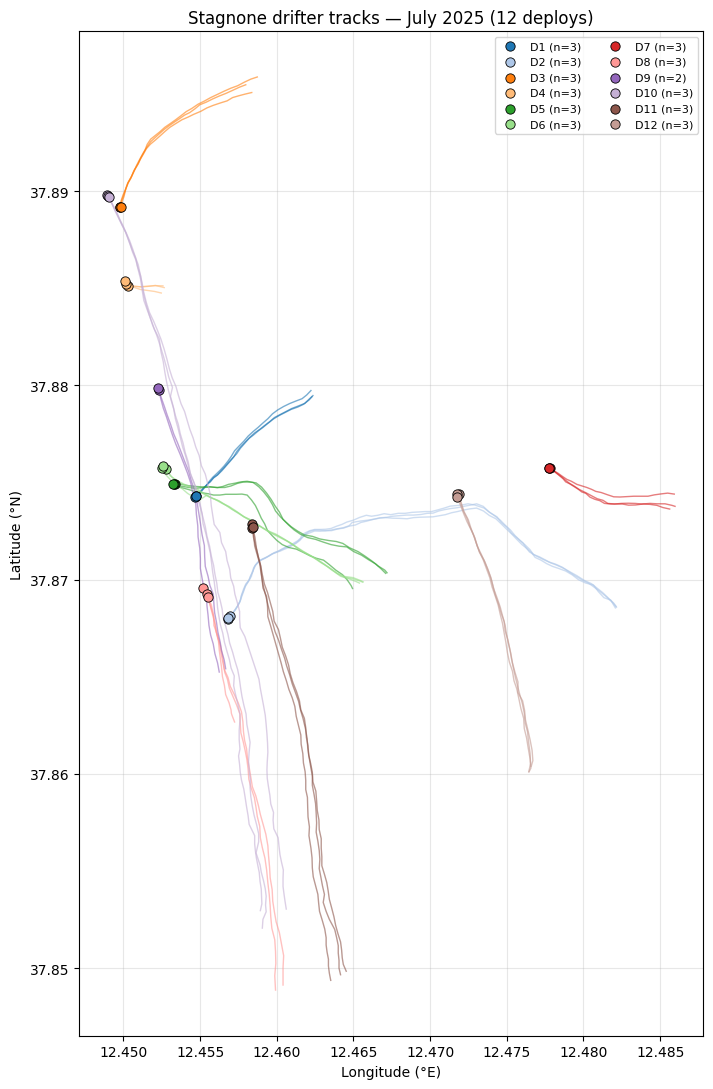

In [8]:
fig, ax = plt.subplots(figsize=(10, 11))
cmap = plt.get_cmap('tab20')
for i, (dep, g) in enumerate(df.groupby('deploy')):
    color = cmap(i % 20)
    for _, sg in g.groupby('source'):
        ax.plot(sg['lon'], sg['lat'], '-', color=color, alpha=0.6, lw=1)
    # release points
    seeds = releases[releases['deploy'] == dep]
    ax.scatter(seeds['lon0'], seeds['lat0'], color=color, s=45, marker='o',
               edgecolor='k', linewidth=0.6, label=f'D{dep} (n={len(seeds)})', zorder=5)

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('Stagnone drifter tracks — July 2025 (12 deploys)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_aspect(1 / np.cos(np.radians(37.87)))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Lagrangian tracking with OpenDrift

OpenDrift is more physically complete than the naive RK2 tracker: it handles Stokes drift, windage (direct wind stress on partially-submerged drifters), horizontal random-walk diffusion, and mesh masking properly.

OpenDrift's native readers don't accept D-Flow FM unstructured format directly:
- `reader_netCDF_CF_unstructured` only supports Cartesian coordinates
- `reader_FVCOM_xarray` expects FVCOM-specific time encoding
- `reader_netCDF_CF_generic` works with rectilinear grids

We regridded the 8-partition v04 map.nc surface velocities onto a rectilinear ~0.002° (~200 m) grid covering July 7-10 (3 days around the drifter campaign) via `scripts/regrid_v04_for_opendrift.py` → `data/processed/v04_surface_current.nc`. The same file also packs `x_wind`/`y_wind` from the FM blended wind file (CF standard_names) so the generic reader serves both currents and the windage term from one source.

Drifter physics in OpenDrift OceanDrift:
- Surface current advection (regridded v04 field)
- Windage / drift factor (`wind_drift_factor` per element; with wind in the same reader, this term is active)
- Horizontal random-walk diffusion

In [9]:
from datetime import timedelta
from opendrift.readers.reader_netCDF_CF_generic import Reader as GenericReader
from opendrift.models.oceandrift import OceanDrift

# Regridded surface current + wind file (v04rAE - AE-only blend).
regridded_nc = processed_dir / 'v04rAE_surface_current.nc'
assert regridded_nc.exists(), f'Missing {regridded_nc} - run scripts/regrid_v04rAE_for_opendrift.py first'
print(f'Using regridded file: {regridded_nc} ({regridded_nc.stat().st_size / 1e6:.1f} MB)')

reader = GenericReader(str(regridded_nc))
print(f'Reader time: {reader.start_time} .. {reader.end_time}')
print(f'Reader domain: lon [{reader.xmin:.3f}, {reader.xmax:.3f}], lat [{reader.ymin:.3f}, {reader.ymax:.3f}]')
print(f'Variables: {reader.variables}')

o = OceanDrift(loglevel=30)
o.add_reader(reader)
o.set_config('drift:horizontal_diffusivity', 0.1)
o.set_config('drift:advection_scheme', 'runge-kutta4')
o.set_config('general:coastline_action', 'previous')

WIND_DRIFT_FACTOR = 0.02
print(f'\nWind drift factor per particle: {WIND_DRIFT_FACTOR} ({WIND_DRIFT_FACTOR*100:.1f}% of wind)')

releases_valid = releases[
    (pd.to_datetime(releases['t0']) >= pd.Timestamp(reader.start_time)) &
    (pd.to_datetime(releases['t0']) <= pd.Timestamp(reader.end_time) - pd.Timedelta(hours=1))
].reset_index(drop=True)
print(f'Valid releases: {len(releases_valid)} / {len(releases)}')

import xarray as xr
_chk = xr.open_dataset(regridded_nc)
def _on_water(lon, lat):
    iy = int(np.argmin(np.abs(_chk.lat.values - lat)))
    ix = int(np.argmin(np.abs(_chk.lon.values - lon)))
    return not np.isnan(_chk['x_sea_water_velocity'].isel(time=0, lat=iy, lon=ix).values)
n_land = sum(1 for _, r in releases_valid.iterrows()
             if not _on_water(r['lon0'], r['lat0']))
print(f'Releases on (regrid) land cells: {n_land} / {len(releases_valid)}')
_chk.close()

for _, row in releases_valid.iterrows():
    o.seed_elements(
        lon=row['lon0'], lat=row['lat0'],
        time=pd.to_datetime(row['t0']).to_pydatetime(),
        number=1, z=0,
        wind_drift_factor=WIND_DRIFT_FACTOR,
    )
print(f'Seeded {o.num_elements_scheduled()} particles')

run_end = pd.Timestamp(reader.end_time).to_pydatetime()
out_file = str(processed_dir / 'opendrift_v04rAE.nc')
print(f'\nRunning OpenDrift until {run_end}...')
o.run(end_time=run_end, time_step=300, time_step_output=600, outfile=out_file)
print(f'\nDone - {o.num_elements_active()} active, {o.num_elements_deactivated()} deactivated')

Using regridded file: C:\Users\Unipa\Documents\StagnoneDT\data\processed\v04rAE_surface_current.nc (92.1 MB)


Reader time: 2025-07-08 00:00:00 .. 2025-07-10 00:00:00
Reader domain: lon [12.000, 12.550], lat [37.700, 38.050]
Variables: ['x_sea_water_velocity', 'y_sea_water_velocity', 'x_wind', 'y_wind', 'wind_speed', 'sea_water_speed']



Wind drift factor per particle: 0.02 (2.0% of wind)
Valid releases: 35 / 35


Releases on (regrid) land cells: 0 / 35


14:06:25 WARNING opendrift:1935: Simulation end is not at an output time step. Extending duration from 1 day, 16:46:00 to 1 day, 16:50:00


...

14:06:32 WARNING opendrift.readers.basereader.structured:324: Data block from C:\Users\Unipa\Documents\StagnoneDT\data\processed\v04rAE_surface_current.nc not large enough to cover element positions within timestep. Buffer size (8) must be increased. See `Variables.set_buffer_size`.


14:06:32 WARNING opendrift.readers.basereader.structured:324: Data block from C:\Users\Unipa\Documents\StagnoneDT\data\processed\v04rAE_surface_current.nc not large enough to cover element positions within timestep. Buffer size (8) must be increased. See `Variables.set_buffer_size`.


14:06:32 WARNING opendrift.readers.basereader.structured:324: Data block from C:\Users\Unipa\Documents\StagnoneDT\data\processed\v04rAE_surface_current.nc not large enough to cover element positions within timestep. Buffer size (8) must be increased. See `Variables.set_buffer_size`.


14:06:32 WARNING opendrift.readers.basereader.structured:324: Data block from C:\Users\Unipa\Documents\StagnoneDT\data\processed\v04rAE_surface_current.nc not large enough to cover element positions within timestep. Buffer size (8) must be increased. See `Variables.set_buffer_size`.



Done - 35 active, 0 deactivated


In [10]:
# Read OpenDrift output and reshape to per-drifter DataFrame
od_out = xr.open_dataset(out_file)
print(f'OpenDrift output: {dict(od_out.sizes)}')
print(f'Variables: {list(od_out.data_vars)}')

sim_tracks_od = []
for traj_idx in range(od_out.sizes['trajectory']):
    lons = od_out.lon.isel(trajectory=traj_idx).values
    lats = od_out.lat.isel(trajectory=traj_idx).values
    ts = pd.to_datetime(od_out.time.values)
    valid = ~np.isnan(lons) & ~np.isnan(lats)
    if valid.sum() < 2:
        continue
    row = releases_valid.iloc[traj_idx]
    arr = pd.DataFrame({
        'time': ts[valid],
        'lon': lons[valid],
        'lat': lats[valid],
        'deploy': row['deploy'],
        'drifter_id': row['drifter_id'],
    })
    sim_tracks_od.append(arr)

sim_df = pd.concat(sim_tracks_od, ignore_index=True) if sim_tracks_od else pd.DataFrame()
print(f'\nSimulated {len(sim_tracks_od)} trajectories ({len(sim_df)} total positions)')
sim_df.to_csv(processed_dir / 'drifter_sim_v04rAE.csv', index=False)
print(f'Saved drifter_sim_v04rAE.csv')

OpenDrift output: {'trajectory': 35, 'time': 246}
Variables: ['status', 'moving', 'age_seconds', 'origin_marker', 'lon', 'lat', 'z', 'wind_drift_factor', 'current_drift_factor', 'terminal_velocity', 'x_sea_water_velocity', 'y_sea_water_velocity', 'sea_surface_height', 'x_wind', 'y_wind', 'upward_sea_water_velocity', 'horizontal_diffusivity', 'sea_surface_wave_significant_height', 'sea_surface_wave_stokes_drift_x_velocity', 'sea_surface_wave_stokes_drift_y_velocity', 'sea_floor_depth_below_sea_level', 'land_binary_mask']

Simulated 35 trajectories (5889 total positions)
Saved drifter_sim_v04rAE.csv


## 7. Skill metrics (per deploy)

When the simulated trajectory file is available, compute per-drifter:
- **Endpoint separation:** great-circle distance between observed and simulated final positions.
- **Path length ratio:** sim_pathlen / obs_pathlen (1 = perfect).
- **Mean heading bias:** circular mean of (sim_heading − obs_heading) along the track.
- **Liu & Weisberg (2011) skill score** `s = 1 − 〈d〉/〈L〉` where d is separation and L is cumulative observed path — the standard trajectory metric in oceanography.

In [11]:
def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def liu_weisberg_skill(obs_lon, obs_lat, sim_lon, sim_lat):
    d = haversine_m(obs_lon, obs_lat, sim_lon, sim_lat)
    step = haversine_m(obs_lon[:-1], obs_lat[:-1], obs_lon[1:], obs_lat[1:])
    L = np.cumsum(np.concatenate([[0.0], step]))
    valid = L > 0
    if not valid.any():
        return np.nan
    c = (d[valid] / L[valid]).sum() / valid.sum()
    return max(0.0, 1.0 - c)

metrics = []
for (dep, drift_id), sim in sim_df.groupby(['deploy', 'drifter_id']):
    sim = sim.sort_values('time').reset_index(drop=True)
    obs = df[(df['deploy'] == dep) & (df['source'] == drift_id)].sort_values('time').reset_index(drop=True)
    if len(obs) < 3:
        continue
    obs_t = obs['time'].values.astype('datetime64[s]').astype(float)
    sim_t = sim['time'].values.astype('datetime64[s]').astype(float)
    mask = (sim_t >= obs_t.min()) & (sim_t <= obs_t.max())
    if mask.sum() < 3:
        continue
    st = sim_t[mask]
    obs_lon = np.interp(st, obs_t, obs['lon'].values)
    obs_lat = np.interp(st, obs_t, obs['lat'].values)
    sim_lon = sim['lon'].values[mask]
    sim_lat = sim['lat'].values[mask]
    endpoint_sep = haversine_m(obs_lon[-1], obs_lat[-1], sim_lon[-1], sim_lat[-1])
    obs_path = haversine_m(obs_lon[:-1], obs_lat[:-1], obs_lon[1:], obs_lat[1:]).sum()
    sim_path = haversine_m(sim_lon[:-1], sim_lat[:-1], sim_lon[1:], sim_lat[1:]).sum()
    skill = liu_weisberg_skill(obs_lon, obs_lat, sim_lon, sim_lat)
    metrics.append({
        'deploy': dep, 'drifter_id': drift_id, 'n_steps': mask.sum(),
        'endpoint_sep_m': endpoint_sep, 'obs_path_m': obs_path, 'sim_path_m': sim_path,
        'path_ratio': sim_path / obs_path if obs_path > 0 else np.nan,
        'LW_skill': skill,
    })

metrics_df = pd.DataFrame(metrics)
print(f'Scored {len(metrics_df)} drifter tracks')
if len(metrics_df):
    print('\n=== Per-drifter metrics (v04rAE) ===')
    print(metrics_df.sort_values(['deploy', 'drifter_id']).round(3).to_string(index=False))
    print(f'\nMean endpoint separation: {metrics_df["endpoint_sep_m"].mean():.0f} m')
    print(f'Mean path ratio:          {metrics_df["path_ratio"].mean():.3f}')
    print(f'Mean L&W skill:           {metrics_df["LW_skill"].mean():.3f}')
    metrics_df.to_csv(processed_dir / 'drifter_metrics_v04rAE.csv', index=False)
    print(f'Saved drifter_metrics_v04rAE.csv')

    # 4-way comparison: v04 / v04r / v04rE5 / v04rAE
    rows = []
    for label, fn in [('v04', 'drifter_metrics_v04.csv'),
                      ('v04r', 'drifter_metrics_v04r.csv'),
                      ('v04rE5', 'drifter_metrics_v04rE5.csv')]:
        p = processed_dir / fn
        if p.exists():
            tmp = pd.read_csv(p)[['deploy', 'drifter_id', 'endpoint_sep_m', 'LW_skill']]
            tmp = tmp.rename(columns={'endpoint_sep_m': f'EP_{label}', 'LW_skill': f'LW_{label}'})
            rows.append(tmp)
    if rows:
        cmp = metrics_df.rename(columns={'endpoint_sep_m': 'EP_v04rAE', 'LW_skill': 'LW_v04rAE'})
        cmp = cmp[['deploy', 'drifter_id', 'EP_v04rAE', 'LW_v04rAE']]
        for tmp in rows:
            cmp = cmp.merge(tmp, on=['deploy', 'drifter_id'], how='left')
        per = cmp.groupby('deploy').agg({c: 'mean' for c in cmp.columns if c.startswith(('EP_', 'LW_'))}).round(2)
        cols = sorted([c for c in per.columns if c.startswith('LW_')]) + sorted([c for c in per.columns if c.startswith('EP_')])
        per = per[cols]
        print('\n=== Per-deploy means: v04 vs v04r vs v04rE5 vs v04rAE ===')
        print(per.to_string())
        print()
        for label in ['v04', 'v04r', 'v04rE5', 'v04rAE']:
            col = f'LW_{label}'
            if col in cmp.columns:
                print(f'Global mean LW {label:7s}: {cmp[col].mean():.3f}')
        if 'LW_v04rE5' in cmp.columns:
            print(f'\nDelta v04rAE - v04rE5: {cmp["LW_v04rAE"].mean() - cmp["LW_v04rE5"].mean():+.3f}')
            print(f'Delta v04rAE - v04r:   {cmp["LW_v04rAE"].mean() - cmp["LW_v04r"].mean():+.3f}')

Scored 35 drifter tracks

=== Per-drifter metrics (v04rAE) ===
 deploy drifter_id  n_steps  endpoint_sep_m  obs_path_m  sim_path_m  path_ratio  LW_skill
      1    0530cnr       14         216.812     843.886  626.554016       0.742     0.746
      1    3500cnr       14         193.686     855.603  658.992004       0.770     0.721
      1    3680cnr       14         231.994     857.472  625.158020       0.729     0.717
      2       1520       41        1751.470    2633.552  463.326996       0.176     0.402
      2        540       40        1717.276    2590.539  463.463989       0.179     0.410
      2       7510       40        1721.456    2577.503  461.479004       0.179     0.410
      3       2520       14         540.327     951.191 1158.067017       1.217     0.492
      3       7520       14         575.487     943.419 1153.541992       1.223     0.475
      3        930       15         637.792    1066.776 1271.276001       1.192     0.473
      4       2520        3          

  sicily2.ldb: 5 polylines
  Stagnone_dxy01_15m.ldb: 1 polylines


14:06:53 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:06:53 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:06:54 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:06:54 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


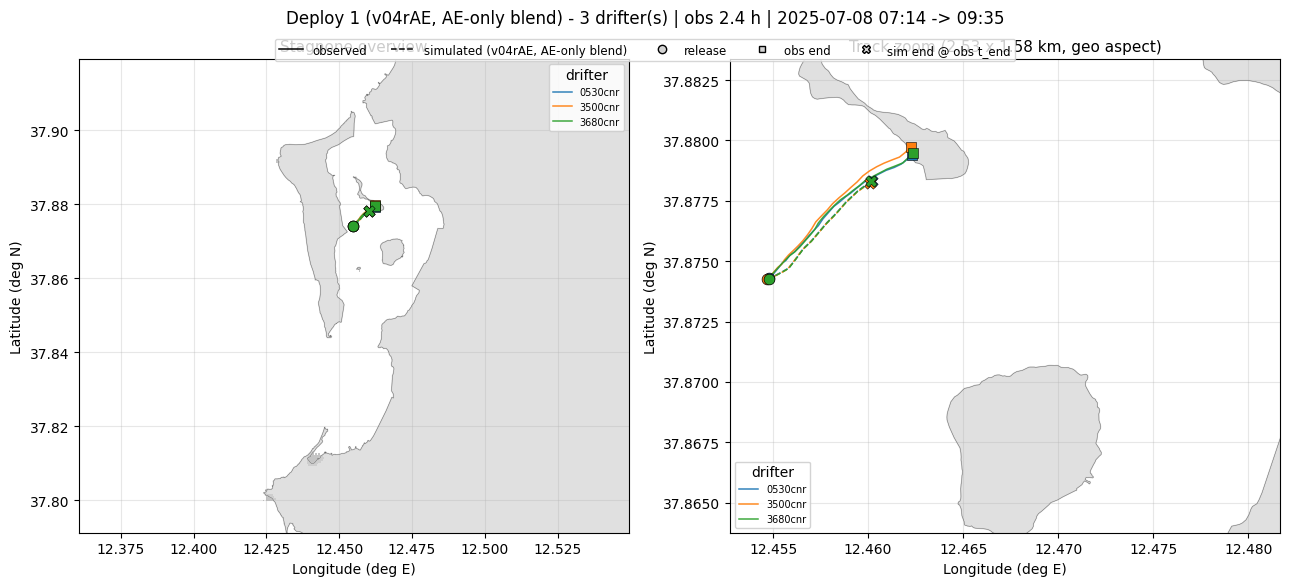

Saved v04rAE_drifter_deploy_01.png


14:06:57 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:06:57 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:06:58 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:06:58 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


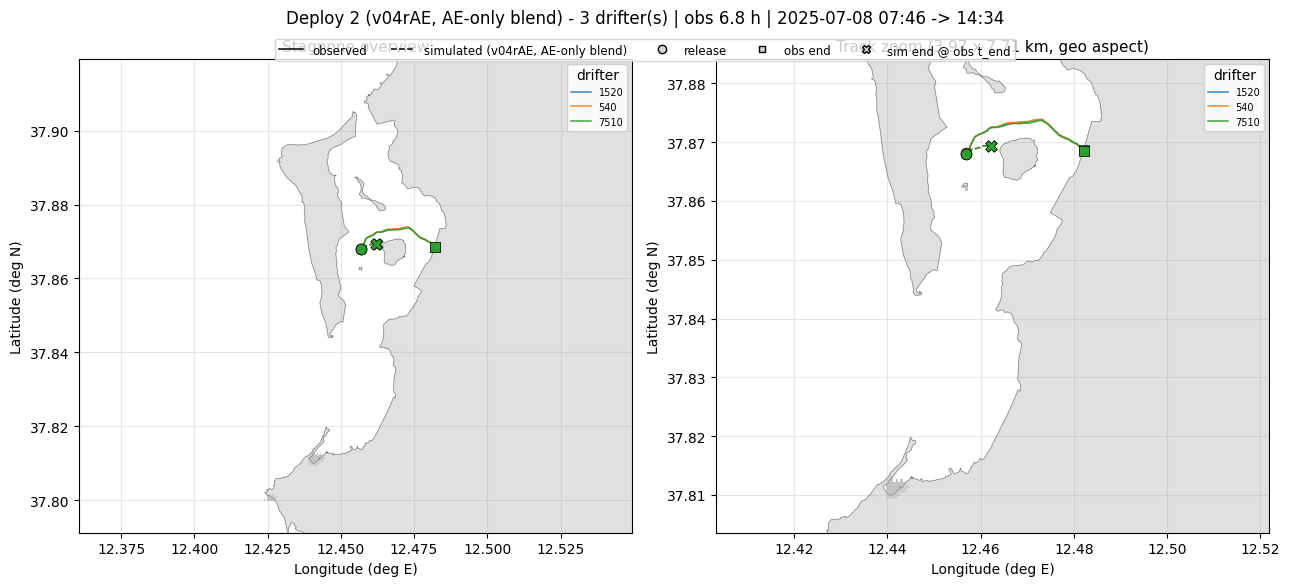

Saved v04rAE_drifter_deploy_02.png


14:07:01 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:01 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:02 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:02 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


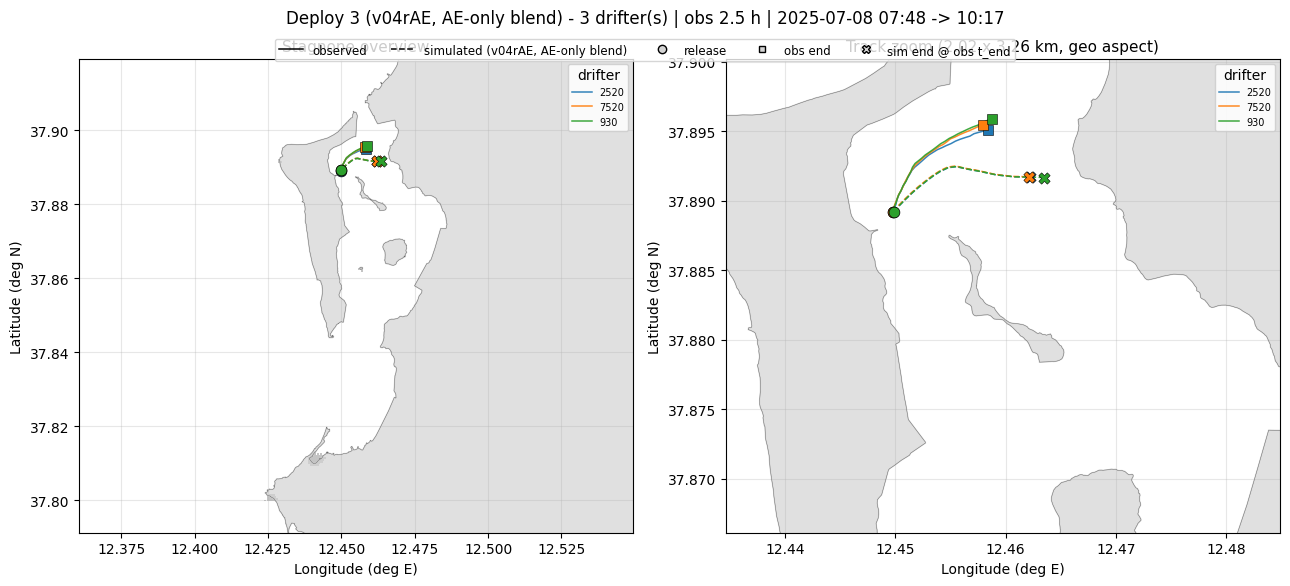

Saved v04rAE_drifter_deploy_03.png


14:07:06 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:06 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:06 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:06 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


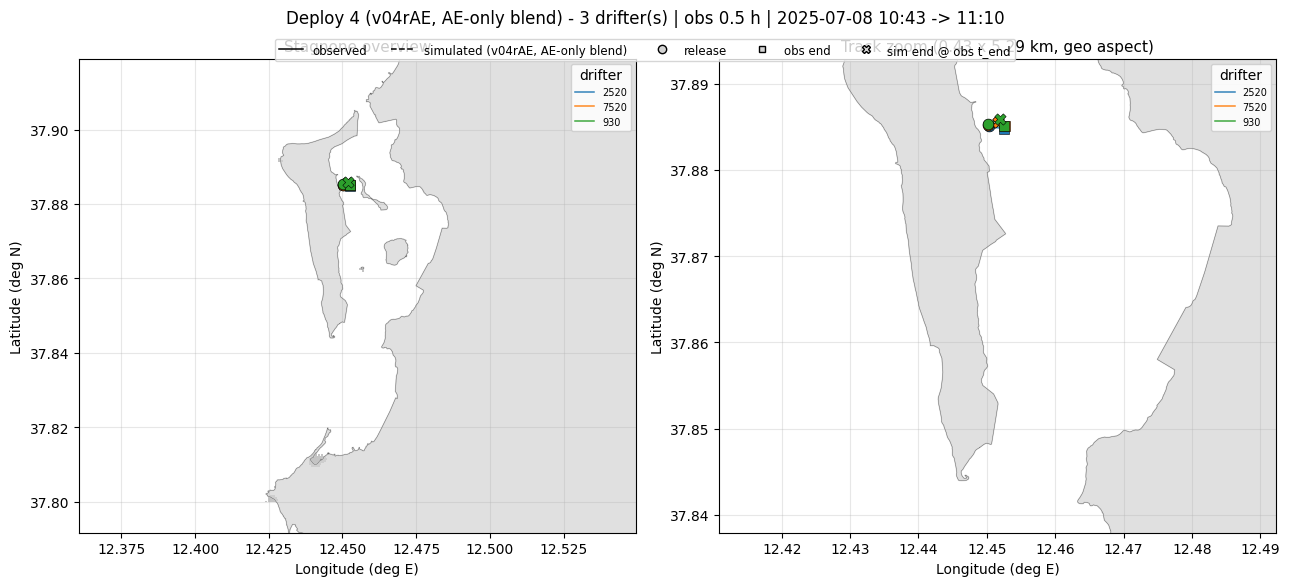

Saved v04rAE_drifter_deploy_04.png


14:07:10 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:10 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:10 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:10 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


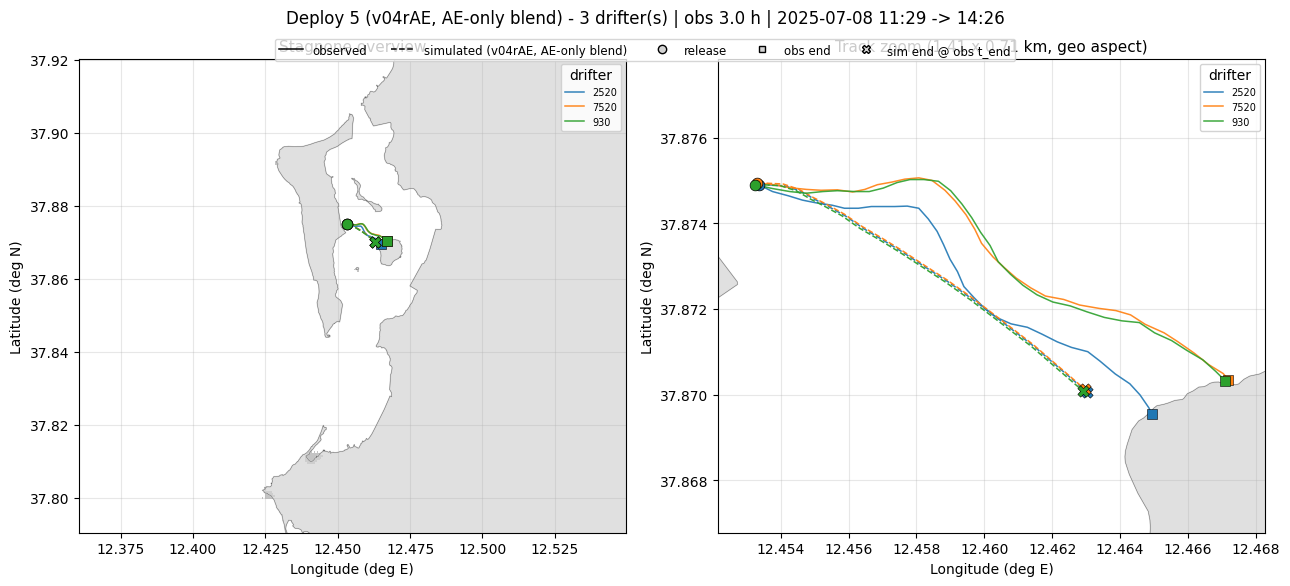

Saved v04rAE_drifter_deploy_05.png


14:07:14 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:14 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:14 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:15 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


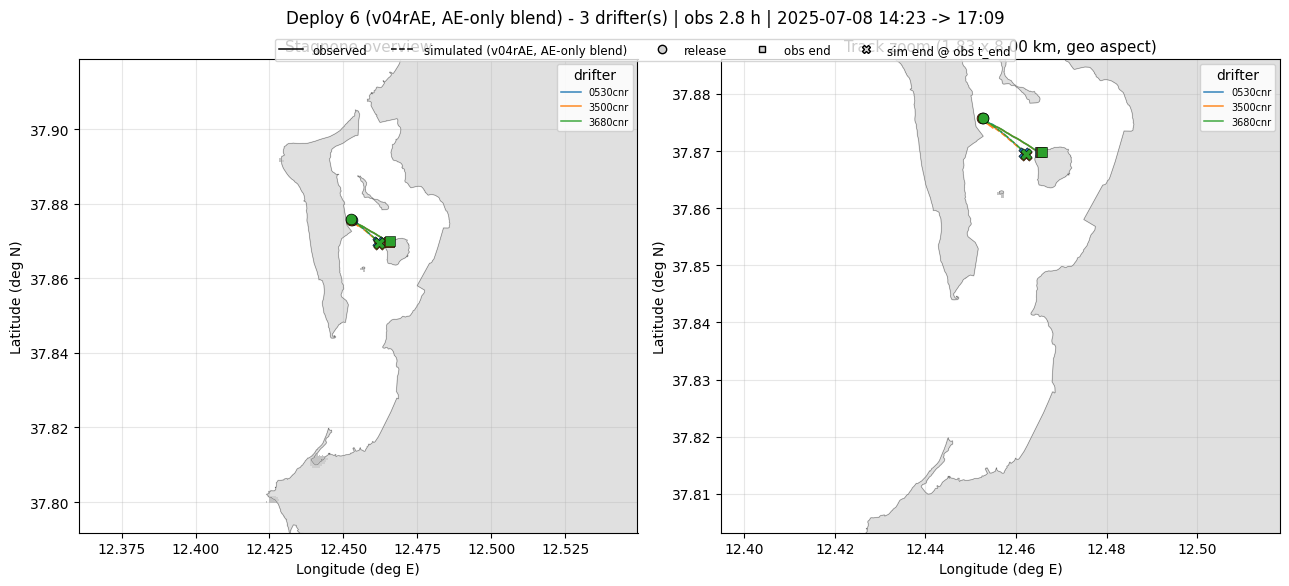

Saved v04rAE_drifter_deploy_06.png


14:07:18 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:18 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:18 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:18 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


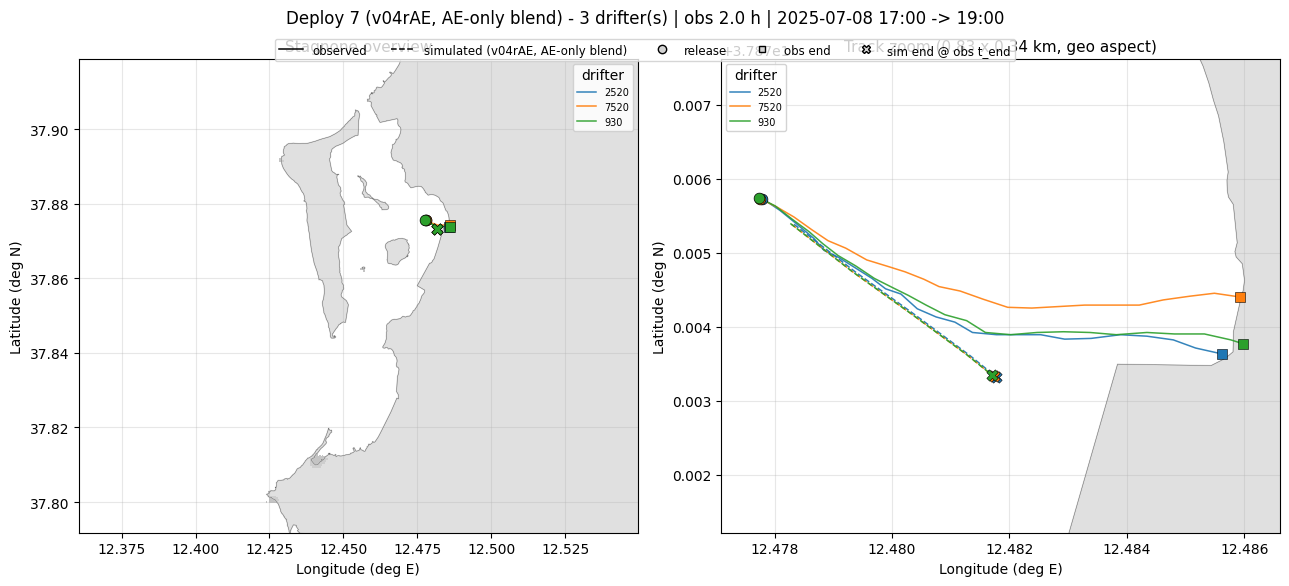

Saved v04rAE_drifter_deploy_07.png


14:07:22 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:22 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:22 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:22 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


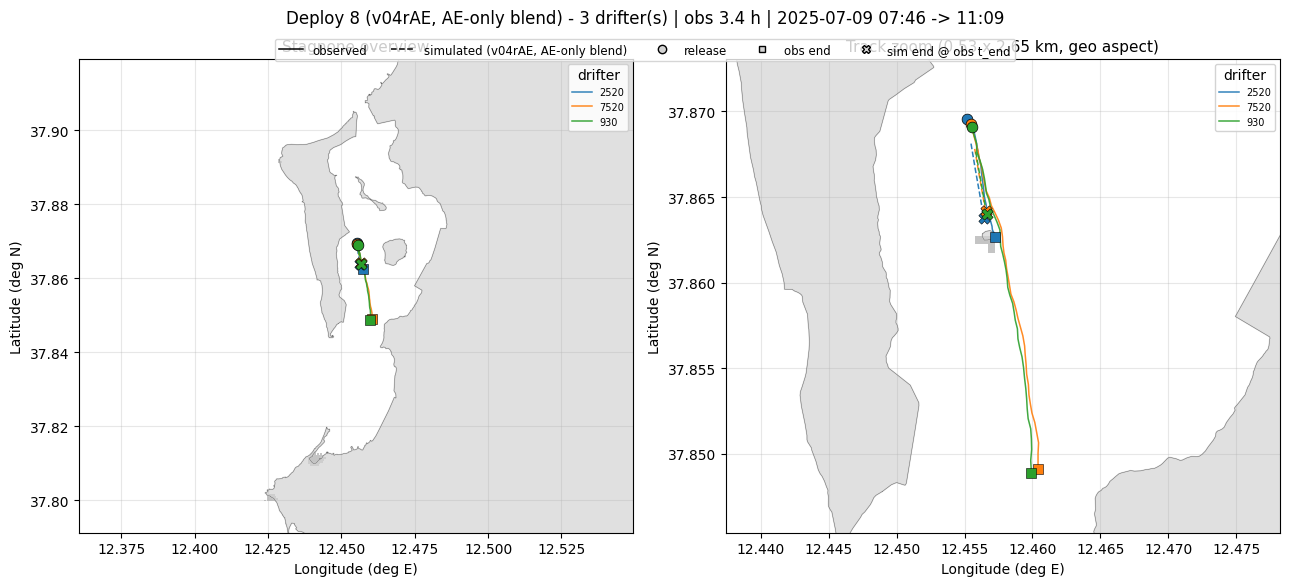

Saved v04rAE_drifter_deploy_08.png


14:07:25 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:25 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:26 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:26 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


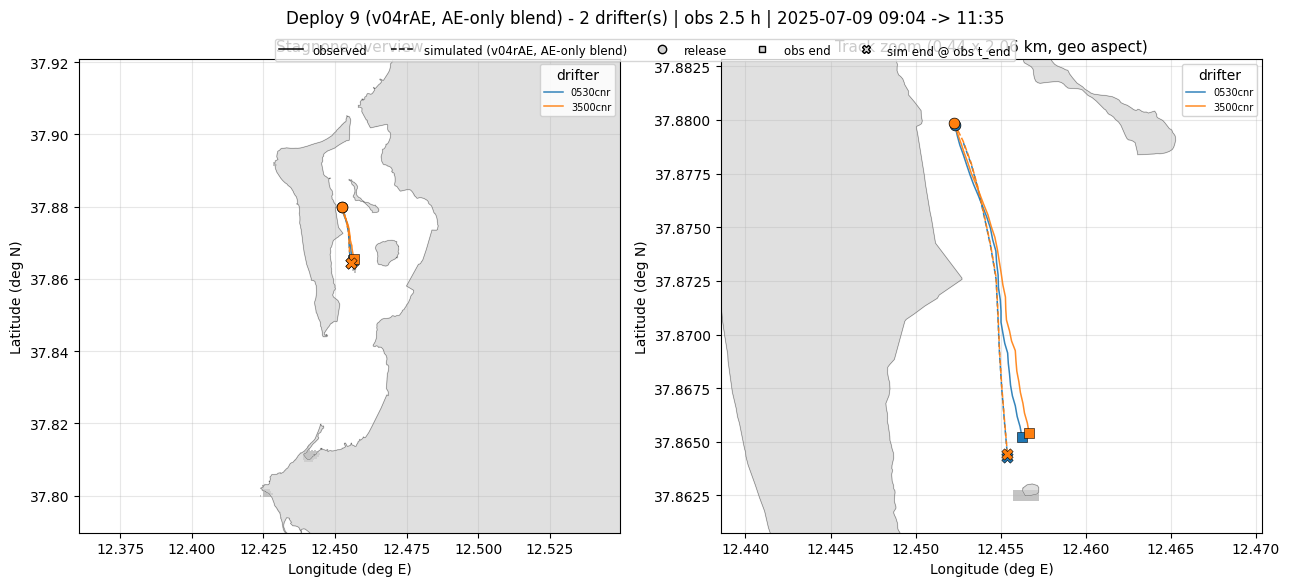

Saved v04rAE_drifter_deploy_09.png


14:07:29 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:29 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:30 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:30 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:30 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:30 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:31 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:31 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


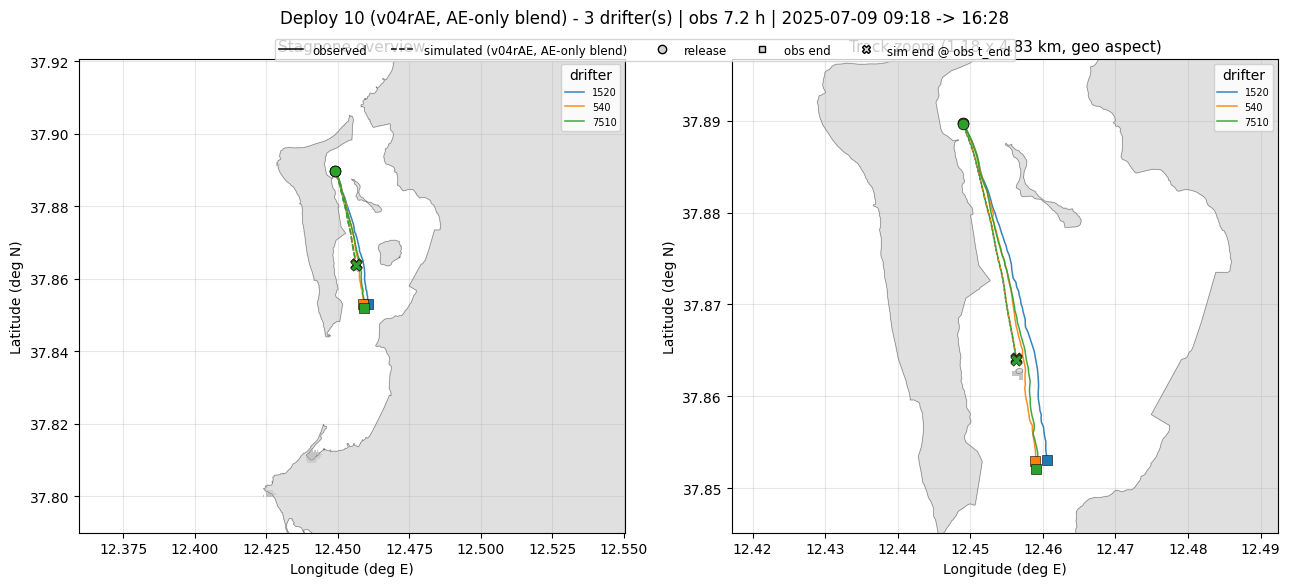

Saved v04rAE_drifter_deploy_10.png


14:07:33 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:33 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:34 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:34 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


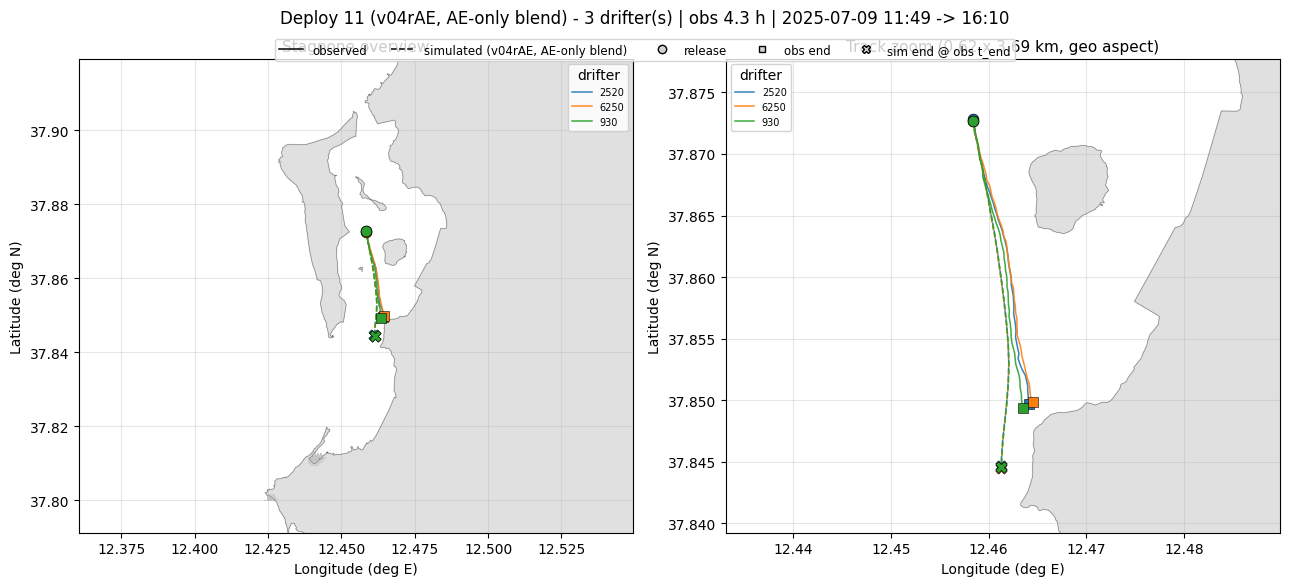

Saved v04rAE_drifter_deploy_11.png


14:07:37 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:37 WARNING matplotlib.axes._base:2096: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14:07:38 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


14:07:38 WARNING matplotlib.axes._base:2088: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


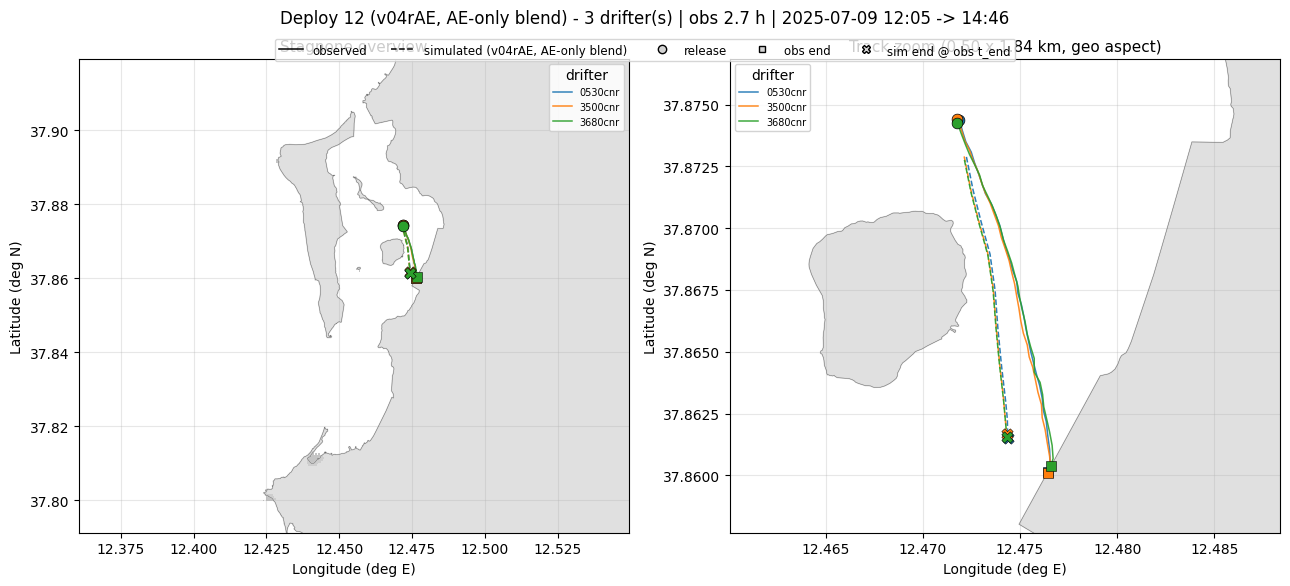

Saved v04rAE_drifter_deploy_12.png


In [12]:
# --- Visual comparison: ONE figure per deploy (v04rAE) ---

def parse_ldb(path):
    polylines = []
    with open(path) as f:
        lines = [ln.strip() for ln in f if ln.strip() and not ln.startswith('*')]
    i = 0
    while i < len(lines):
        i += 1
        if i >= len(lines):
            break
        npts = int(lines[i].split()[0])
        i += 1
        coords = np.array([list(map(float, lines[i+k].split()[:2])) for k in range(npts)])
        polylines.append(coords)
        i += npts
    return polylines

ldb_paths = [
    project_root / 'model' / 'dflowfm_v04rAE' / 'sicily2.ldb',
    project_root / 'model' / 'dflowfm_v04rAE' / 'Stagnone_dxy01_15m.ldb',
]
landboundary = []
for p in ldb_paths:
    polys = parse_ldb(p)
    landboundary.extend(polys)
    print(f'  {p.name}: {len(polys)} polylines')

poly_bboxes = np.array([[p[:, 0].min(), p[:, 0].max(), p[:, 1].min(), p[:, 1].max()] for p in landboundary])

land_mask_path = processed_dir / 'v04_land_mask_50m.nc'
land_ds = xr.open_dataset(land_mask_path)
land_lon = land_ds.lon.values
land_lat = land_ds.lat.values
land_arr = land_ds.land.values

def visible_polys(lon_min, lon_max, lat_min, lat_max):
    keep = (poly_bboxes[:, 1] >= lon_min) & (poly_bboxes[:, 0] <= lon_max) & \
           (poly_bboxes[:, 3] >= lat_min) & (poly_bboxes[:, 2] <= lat_max)
    return np.where(keep)[0]

def draw_land(ax):
    lon_min, lon_max = ax.get_xlim()
    lat_min, lat_max = ax.get_ylim()
    ix = (land_lon >= lon_min) & (land_lon <= lon_max)
    iy = (land_lat >= lat_min) & (land_lat <= lat_max)
    sub = land_arr[np.ix_(iy, ix)]
    if sub.size > 0:
        ax.pcolormesh(land_lon[ix], land_lat[iy], np.where(sub == 1, 1.0, np.nan),
                      cmap='Greys', vmin=0, vmax=2.0, shading='auto',
                      zorder=0, rasterized=True, alpha=0.55)
    for idx in visible_polys(lon_min, lon_max, lat_min, lat_max):
        poly = landboundary[idx]
        ax.fill(poly[:, 0], poly[:, 1], color='lightgrey', alpha=0.7, zorder=1)
        ax.plot(poly[:, 0], poly[:, 1], '-', color='dimgrey', lw=0.35, zorder=2)

sim_df['time'] = pd.to_datetime(sim_df['time'])
df['time'] = pd.to_datetime(df['time'])

from matplotlib.lines import Line2D
LEGEND_TYPE = [
    Line2D([0], [0], color='black', lw=1.1, linestyle='-', label='observed'),
    Line2D([0], [0], color='black', lw=1.1, linestyle='--', label='simulated (v04rAE, AE-only blend)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',
           markeredgecolor='k', markersize=6, label='release', linestyle=''),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgrey',
           markeredgecolor='k', markersize=5, label='obs end', linestyle=''),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='lightgrey',
           markeredgecolor='k', markersize=6, label='sim end @ obs t_end', linestyle=''),
]

STAGNONE_BBOX = dict(lon=(12.420, 12.490), lat=(37.800, 37.9105))
ASPECT_LAT = 37.87
ASPECT = 1.0 / np.cos(np.radians(ASPECT_LAT))
HALF_PAD = (1.0 / np.sqrt(0.75) - 1) / 2

def _plot_tracks_on_ax(ax, obs_dep, sim_dep, sources):
    cmap = plt.get_cmap('tab10')
    for i, src in enumerate(sources):
        color = cmap(i % 10)
        obs_g = obs_dep[obs_dep['source'] == src].sort_values('time')
        sim_g = sim_dep[sim_dep['drifter_id'] == src].sort_values('time')
        t0, t1 = obs_g['time'].min(), obs_g['time'].max()
        sim_clip = sim_g[(sim_g['time'] >= t0) & (sim_g['time'] <= t1)]
        ax.plot(obs_g['lon'], obs_g['lat'], '-', color=color, alpha=0.9, lw=1.1, label=str(src), zorder=4)
        if len(sim_clip):
            ax.plot(sim_clip['lon'], sim_clip['lat'], '--', color=color, alpha=0.95, lw=1.1, zorder=4)
        ax.scatter(obs_g['lon'].iloc[0], obs_g['lat'].iloc[0], color=color, s=60, marker='o',
                   edgecolor='k', linewidth=0.5, zorder=6)
        ax.scatter(obs_g['lon'].iloc[-1], obs_g['lat'].iloc[-1], color=color, s=46, marker='s',
                   edgecolor='k', linewidth=0.4, zorder=6)
        if len(sim_clip):
            ax.scatter(sim_clip['lon'].iloc[-1], sim_clip['lat'].iloc[-1], color=color, s=67,
                       marker='X', edgecolor='k', linewidth=0.4, zorder=6)


def plot_deploy(dep):
    obs_dep = df[df['deploy'] == dep]
    sim_dep = sim_df[sim_df['deploy'] == dep]
    if obs_dep.empty:
        return
    sources = sorted(obs_dep['source'].unique())
    t0, t1 = obs_dep['time'].min(), obs_dep['time'].max()
    dur_h = (t1 - t0).total_seconds() / 3600.0
    fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(13, 6))
    fig.subplots_adjust(left=0.05, right=0.99, top=0.84, bottom=0.10, wspace=0.04)
    ax_full.set_xlim(*STAGNONE_BBOX['lon']); ax_full.set_ylim(*STAGNONE_BBOX['lat'])
    draw_land(ax_full); _plot_tracks_on_ax(ax_full, obs_dep, sim_dep, sources)
    ax_full.set_aspect(ASPECT, adjustable='datalim')
    ax_full.set_title('Stagnone overview', fontsize=11)
    ax_full.set_xlabel('Longitude (deg E)'); ax_full.set_ylabel('Latitude (deg N)')
    ax_full.grid(alpha=0.3); ax_full.legend(loc='best', fontsize=7, title='drifter', framealpha=0.85)
    all_lons = pd.concat([obs_dep['lon'], sim_dep['lon']]) if not sim_dep.empty else obs_dep['lon']
    all_lats = pd.concat([obs_dep['lat'], sim_dep['lat']]) if not sim_dep.empty else obs_dep['lat']
    lon_span = max(all_lons.max() - all_lons.min(), 0.001)
    lat_span = max(all_lats.max() - all_lats.min(), 0.001)
    zlon_min = all_lons.min() - lon_span * HALF_PAD
    zlon_max = all_lons.max() + lon_span * HALF_PAD
    zlat_min = all_lats.min() - lat_span * HALF_PAD
    zlat_max = all_lats.max() + lat_span * HALF_PAD
    ax_zoom.set_xlim(zlon_min, zlon_max); ax_zoom.set_ylim(zlat_min, zlat_max)
    draw_land(ax_zoom); _plot_tracks_on_ax(ax_zoom, obs_dep, sim_dep, sources)
    ax_zoom.set_aspect(ASPECT, adjustable='datalim')
    width_km = (zlon_max - zlon_min) * 111 * np.cos(np.radians(ASPECT_LAT))
    height_km = (zlat_max - zlat_min) * 111
    ax_zoom.set_title(f'Track zoom ({width_km:.2f} x {height_km:.2f} km, geo aspect)', fontsize=11)
    ax_zoom.set_xlabel('Longitude (deg E)'); ax_zoom.set_ylabel('Latitude (deg N)')
    ax_zoom.grid(alpha=0.3); ax_zoom.legend(loc='best', fontsize=7, title='drifter', framealpha=0.85)
    fig.suptitle(f'Deploy {dep} (v04rAE, AE-only blend) - {len(sources)} drifter(s) | obs {dur_h:.1f} h | '
                 f'{t0.strftime("%Y-%m-%d %H:%M")} -> {t1.strftime("%H:%M")}',
                 fontsize=12, y=0.97)
    fig.legend(handles=LEGEND_TYPE, loc='upper center', ncol=5, fontsize=8.5,
               bbox_to_anchor=(0.5, 0.93), frameon=True)
    out = fig_dir / f'v04rAE_drifter_deploy_{dep:02d}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {out.name}')

for dep in sorted(sim_df['deploy'].unique()):
    plot_deploy(dep)

## 8. Interpretation + next steps

**Expected behavior:**
- Campaign was wind-driven during July 8-9 with surface drift dominated by wind stress on the drifters + surface current
- v04 has time-varying SWAN coupling on 2 nested grids (outer ~400 m / inner ~100 m), so wave-induced Stokes drift is real (not constant-BC like v03a was)
- Endpoint separations of 50-500 m over 6 hours are typical; >1 km indicates systematic surface-drift underestimation
- L&W skill > 0.5 is good; > 0.7 excellent

**If systematic under-drift (paths shorter than observed, low skill):**
- v04 wind drag (`icdtyp=4` Charnock) may be too weak — try fixed `icdtyp=1` with higher coefficient
- Stokes drifter shape has a drag coefficient ~2-3% of wind: surface current alone won't match — bump `WIND_DRIFT_FACTOR` to 0.03 or 0.04
- Verify the 2% windage is taking effect: `o.elements_scheduled.wind_drift_factor` after seeding

**If systematic over-drift (paths too long):**
- Horizontal diffusivity may need damping
- Check wind file: is blended wind at the right intensity?

**Tuning knobs:**
1. `WIND_DRIFT_FACTOR` — 1% (deep) to 4% (shallow); 2% is the first guess
2. `drift:horizontal_diffusivity` — currently 0.1 m²/s; raise to 1-10 m²/s if want more spread
3. The regridded NetCDF could include surface Stokes drift directly (FM `mesh2d_ust`/`mesh2d_vst`) instead of relying on windage — would need a `regrid_v04` extension

**Comparison with v04-no-waves (deferred):**
To isolate the contribution of wave coupling to drifter skill, the cleaner experiment is v04 (with ondas) vs a v04-no-waves clone (SWAN disabled in DIMR), keeping all other config identical. v03a is not a valid baseline (its WL boundary had TPXO double-counting); v03d has waves too. See memory `v04_no_waves_comparison_option`.

**Next paper milestone (Paper 1 — 3D hydrodynamics):**
Run the per-drifter table at a couple of `WIND_DRIFT_FACTOR` values, ideally with the no-waves variant for the wave-effect breakdown, and report skill scores in a table for the ~12-15 representative drifters across the 12 deploys.